In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr

from armored.models import *
from armored.preprocessing import *

import itertools

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt


params = {
    'figure.figsize': (7, 5),       # Figure size in inches
    'figure.dpi': 300,               # Resolution in dots per inch
    'axes.labelsize': 7,            # Font size of the axes labels
    'axes.titlesize': 7,            # Font size of the subplot titles
    'axes.titlepad': 10,             # Spacing between the subplot title and the plot
    'axes.linewidth': .5,           # Width of the axis lines
    'axes.grid': False,              # Display grid lines
    'axes.grid.axis': 'both',        # Display grid lines for both major and minor ticks
    'grid.alpha': 0.5,               # Transparency of the grid lines
    'grid.linewidth': 0.5,           # Width of the grid lines
    'xtick.labelsize': 7,           # Font size of the x-axis tick labels
    'ytick.labelsize': 7,           # Font size of the y-axis tick labels
    'xtick.major.size': 3,           # Length of the major x-axis ticks in points
    'xtick.major.width': .5,        # Width of the major x-axis ticks
    'ytick.major.size': 3,           # Length of the major y-axis ticks in points
    'ytick.major.width': .5,        # Width of the major y-axis ticks
    'xtick.minor.size': 2,           # Length of the minor x-axis ticks in points
    'xtick.minor.width': .5,        # Width of the minor x-axis ticks
    'ytick.minor.size': 2,           # Length of the minor y-axis ticks in points
    'ytick.minor.width': .5,        # Width of the minor y-axis ticks
    'xtick.direction': 'in',         # Direction of the x-axis ticks ('in', 'out', or 'inout')
    'ytick.direction': 'in',         # Direction of the y-axis ticks ('in', 'out', or 'inout')
    'legend.fontsize': 7,           # Font size of the legend
    'legend.frameon': True,          # Whether to draw a frame around the legend
    'legend.facecolor': 'inherit',   # Background color of the legend
    'legend.edgecolor': '0.8',       # Edge color of the legend
    'legend.framealpha': 0.8,        # Transparency of the legend frame
    'legend.loc': 'best',            # Location of the legend ('best', 'upper right', 'upper left', 'lower left', etc.)
    'legend.title_fontsize': 7,     # Font size of the legend title
    'svg.fonttype': 'none'           # Output font type for PDF files
}

plt.rcParams.update(params)

In [2]:
# import mouse NGS 
mouse_ngs_ipx_cel = pd.read_csv('data/mouse/MouseNGS_IPX_CEL.csv')
mouse_ngs_ipx = mouse_ngs_ipx_cel.iloc[np.isin(mouse_ngs_ipx_cel['Diet'].values, 'Inulin-Pectin-Xylan')]
mouse_ngs_cel = mouse_ngs_ipx_cel.iloc[np.isin(mouse_ngs_ipx_cel['Diet'].values, 'Cellulose')] 
mouse_ngs_xyl = pd.read_csv('data/mouse/MouseNGS_XYL.csv')

# import gc data
# timepoint 6 diet/comm group 2 rep 3 is considered an outlier - set to NaN 
mouse_gc = pd.read_csv('data/mouse/GC_table_rm_outlier.csv')

# take measurements at days 8, 10, 15
mouse_gc = mouse_gc.iloc[mouse_gc.Timepoint.values>=3]

In [3]:
# dictionaries with objective components 
instability_dict = {}
diversity_dict = {}
butyrate_dict = {}

In [4]:
# populate butyrate dict

# group 1 is HiComm-IPX, group 2 is HiComm-Cel, group 3 is LoComm-Xyl
hicomm_ipx_gc = mouse_gc.iloc[mouse_gc['Group'].values==1] 
hicomm_cel_gc = mouse_gc.iloc[mouse_gc['Group'].values==2]
locomm_xyl_gc = mouse_gc.iloc[mouse_gc['Group'].values==3]

hicomm_ipx_butyrate_df = hicomm_ipx_gc.iloc[np.isin(hicomm_ipx_gc['VFA'].values, 'Butyrate')].copy()
hicomm_cel_butyrate_df = hicomm_cel_gc.iloc[np.isin(hicomm_cel_gc['VFA'].values, 'Butyrate')].copy()
locomm_xyl_butyrate_df = locomm_xyl_gc.iloc[np.isin(locomm_xyl_gc['VFA'].values, 'Butyrate')].copy()

# save average value over timepoints for each replicate 
hicomm_ipx_butyrate= []
for rep, df_rep in hicomm_ipx_butyrate_df.groupby('Rep'):
    hicomm_ipx_butyrate.append(np.mean(df_rep['umol_g'].values))

hicomm_cel_butyrate= []
for rep, df_rep in hicomm_cel_butyrate_df.groupby('Rep'):
    hicomm_cel_butyrate.append(np.nanmean(df_rep['umol_g'].values))

locomm_xyl_butyrate= []
for rep, df_rep in locomm_xyl_butyrate_df.groupby('Rep'):
    locomm_xyl_butyrate.append(np.mean(df_rep['umol_g'].values))

butyrate_dict['HiComm-IPX'] = np.quantile(hicomm_ipx_butyrate, [.25,.5,.75])  # [np.mean(hicomm_ipx_butyrate), np.std(hicomm_ipx_butyrate)] 
butyrate_dict['HiComm-Cel'] = np.quantile(hicomm_cel_butyrate, [.25,.5,.75])  # [np.mean(hicomm_cel_butyrate), np.std(hicomm_cel_butyrate)]
butyrate_dict['LoComm-Xyl'] = np.quantile(locomm_xyl_butyrate, [.25,.5,.75])  # [np.mean(locomm_xyl_butyrate), np.std(locomm_xyl_butyrate)]

In [5]:
# populate stability dict
hicomm_ipx_instability = []  # list over replicates
hicomm_cel_instability = []  # list over replicates
locomm_xyl_instability = []  # list over replicates 

for rep_num, mouse_ngs in mouse_ngs_ipx.groupby('MouseRep'):

    rel_abd = mouse_ngs[['ACrel', 'BArel', 'BHrel', 'BLrel', 'BUrel', 'CHrel', 'DFrel', 'FPrel', 'RIrel']] 
    instability = np.mean(np.std(rel_abd.values[-2:], axis=0))
    hicomm_ipx_instability.append(instability)

for rep_num, mouse_ngs in mouse_ngs_cel.groupby('MouseRep'):

    rel_abd = mouse_ngs[['ACrel', 'BArel', 'BHrel', 'BLrel', 'BUrel', 'CHrel', 'DFrel', 'FPrel', 'RIrel']] 
    instability = np.mean(np.std(rel_abd.values[-2:], axis=0))
    hicomm_cel_instability.append(instability)

for rep_num, mouse_ngs in mouse_ngs_xyl.groupby('MouseRep'):

    rel_abd = mouse_ngs[['BArel', 'BLrel', 'CCrel', 'CHrel', 'DFrel', 'ERrel', 'FPrel', 'PCrel']] 
    instability = np.mean(np.std(rel_abd.values[-2:], axis=0))
    locomm_xyl_instability.append(instability)

instability_dict['HiComm-IPX'] = np.quantile(hicomm_ipx_instability, [.25, .5, .75])  # [np.mean(hicomm_ipx_instability), np.std(hicomm_ipx_instability)]
instability_dict['HiComm-Cel'] = np.quantile(hicomm_cel_instability, [.25, .5, .75])  # [np.mean(hicomm_cel_instability), np.std(hicomm_cel_instability)]
instability_dict['LoComm-Xyl'] = np.quantile(locomm_xyl_instability, [.25, .5, .75])  # [np.mean(locomm_xyl_instability), np.std(locomm_xyl_instability)]

In [6]:
# populate diversity dict 
hicomm_ipx_diversity = []  # list over replicates
hicomm_cel_diversity = []  # list over replicates
locomm_xyl_diversity = []  # list over replicates   

def shannon_diversity(abundances):
    """Calculate the Shannon diversity index for a given abundance distribution."""
    # Filter out zero abundances to avoid log(0)
    abundances = abundances[abundances > 0]
    # Calculate proportions
    proportions = abundances / np.sum(abundances)
    # Calculate Shannon diversity
    shannon_index = -np.sum(proportions * np.log(proportions))
    return shannon_index

for rep_num, mouse_ngs in mouse_ngs_ipx.groupby('MouseRep'):

    rel_abd = mouse_ngs[['ACrel', 'BArel', 'BHrel', 'BLrel', 'BUrel', 'CHrel', 'DFrel', 'FPrel', 'RIrel']] 
    diversity = shannon_diversity(rel_abd.values[-1, :])
    hicomm_ipx_diversity.append(diversity)  

for rep_num, mouse_ngs in mouse_ngs_cel.groupby('MouseRep'):
    
    rel_abd = mouse_ngs[['ACrel', 'BArel', 'BHrel', 'BLrel', 'BUrel', 'CHrel', 'DFrel', 'FPrel', 'RIrel']] 
    diversity = shannon_diversity(rel_abd.values[-1, :])
    hicomm_cel_diversity.append(diversity)

for rep_num, mouse_ngs in mouse_ngs_xyl.groupby('MouseRep'):
    
    rel_abd = mouse_ngs[['BArel', 'BLrel', 'CCrel', 'CHrel', 'DFrel', 'ERrel', 'FPrel', 'PCrel']] 
    diversity = shannon_diversity(rel_abd.values[-1, :])
    locomm_xyl_diversity.append(diversity)

diversity_dict['HiComm-IPX'] = np.quantile(hicomm_ipx_diversity, [.25, .5, .75])  # [np.mean(hicomm_ipx_diversity), np.std(hicomm_ipx_diversity)]
diversity_dict['HiComm-Cel'] = np.quantile(hicomm_cel_diversity, [.25, .5, .75])  # [np.mean(hicomm_cel_diversity), np.std(hicomm_cel_diversity)]
diversity_dict['LoComm-Xyl'] = np.quantile(locomm_xyl_diversity, [.25, .5, .75])  # [np.mean(locomm_xyl_diversity), np.std(locomm_xyl_diversity)]

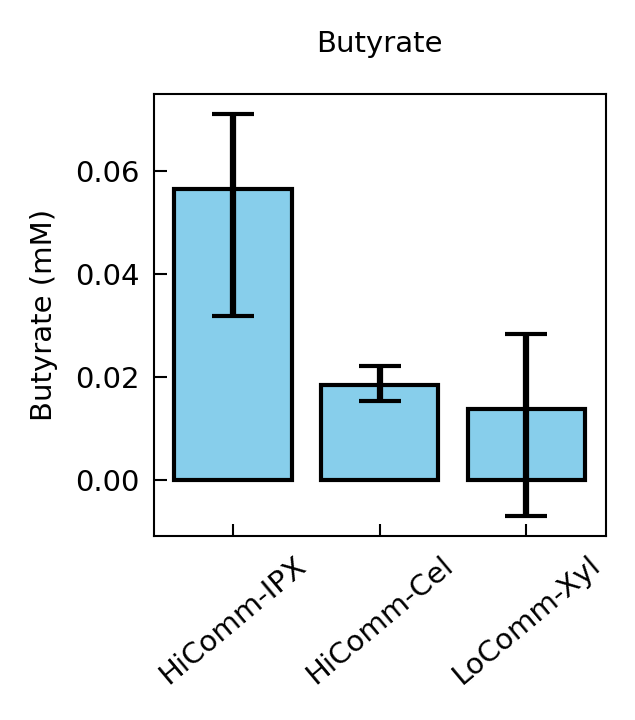

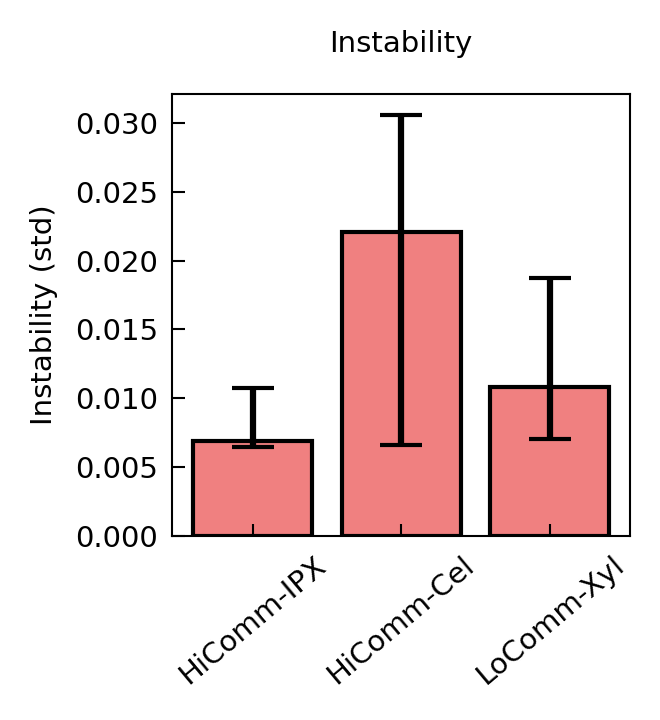

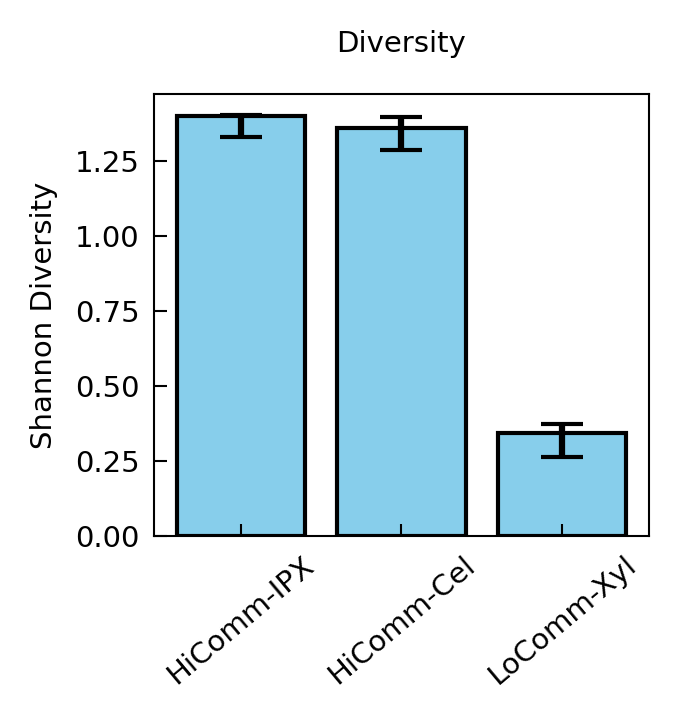

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dict_with_stats(data_dict, title, ylabel, color='skyblue'):
    keys = list(data_dict.keys())

    heights = []
    yerr_lower = []
    yerr_upper = []

    for k in keys:
        v = np.atleast_1d(data_dict[k])

        # Case 0: empty
        if len(v) == 0:
            heights.append(0.0)
            yerr_lower.append(0.0)
            yerr_upper.append(0.0)

        # Case 1: single value
        elif len(v) == 1:
            val = float(v[0])
            heights.append(val)
            yerr_lower.append(0.0)
            yerr_upper.append(0.0)

        # Case 2: mean ± std
        elif len(v) == 2:
            mean = np.mean(v)
            std = np.std(v, ddof=1) if len(v) > 1 else 0.0
            heights.append(mean)
            yerr_lower.append(std)
            yerr_upper.append(std)

        # Case 3: assume [q1, median, q3]
        elif len(v) == 3:
            median = v[1]
            lower = median - v[0]
            upper = v[2] - median
            heights.append(median)
            yerr_lower.append(lower)
            yerr_upper.append(upper)

        else:
            raise ValueError(f"Unexpected number of values for key '{k}': {v}")

    fig, ax = plt.subplots(figsize=(2.3, 2.5))
    ax.bar(
        keys,
        heights,
        yerr=[yerr_lower, yerr_upper],
        capsize=5,
        color=color,
        edgecolor='k'
    )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(keys, rotation=40)

    plt.tight_layout()
    plt.savefig(f'figures/mouse_objectives/{title}_objectives_barplot.svg')
    plt.show()

plot_dict_with_stats(butyrate_dict, "Butyrate", "Butyrate (mM)")
plot_dict_with_stats(instability_dict, "Instability", "Instability (std)", color='lightcoral')
plot_dict_with_stats(diversity_dict, "Diversity", "Shannon Diversity")

In [8]:
# same for in-vitro data (just hicomm-ipx and locomm-xyl)

# dictionaries with objective components 
instability_dict = {
    'HiComm-IPX': [],
    'HiComm-Cel': [],
    'LoComm-Xyl': []
}

diversity_dict = {
    'HiComm-IPX': [],
    'HiComm-Cel': [],
    'LoComm-Xyl': []
}

butyrate_dict = {
    'HiComm-IPX': [],
    'HiComm-Cel': [],
    'LoComm-Xyl': []
}


# only have 1 replicate for locomm-xyl 
pred_df = pd.read_csv("space/sampled_space.csv")
locomm_exp_name = 'BA-BL-CC-CH-DF-ER-FP-PC-Xylan'
locomm_df = pred_df[pred_df['Experiments']==locomm_exp_name]

# load data with replicates for hicomm-ipx 
hicomm_data = pd.read_csv("data/exp4/BC064B_bestExp_dataframe_clean_20240117_v2.csv")
hicomm_exp_name = 'AC-BA-BH-BL-BU-CH-DF-FP-RI-4Inulin-1Pectin-1Xylan'
hicomm_data = hicomm_data.iloc[np.isin(hicomm_data['Treatment'].values, hicomm_exp_name)].copy() 

In [9]:
# define variable names
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']

# log that ignores zeros
def zlog(x):
    x[x <= 0] = 1
    return np.log(x)

# shannon diversity
def shannon(y):
    y = np.clip(y, 0, np.inf)
    if np.nansum(y) > 0:
        y_rel = y / np.nansum(y)
        return np.nansum(-zlog(y_rel)*y_rel)
    else:
        return np.nan

# determine best previously observed values of objectives
b_max = 24.206144
d_max = 2.2569
v_max = 0.05319

# define objective 
def objective(y):
    
    # y is measured exp data [n_time, n_species + n_metabolites]
    if len(y)>2:
        # endpoint shannon diversity
        diversity = shannon(y[-1, :len(species)])

        # variance in species abundances in last two passages
        if np.any(np.isnan(y[-2:, :len(species)])):
            instability = np.nan
        else:
            species_stdv = np.std(y[-2:, :len(species)], 0)
            instability  = np.where(species_stdv>0, species_stdv, 0).mean() 

        # endpoint butyrate production 
        butyrate =  y[-1, -2]   

        # scaled objective 
        scaled_obj = diversity / d_max - instability / v_max + butyrate / b_max

        return diversity, instability, butyrate, scaled_obj
    
    else:
        return np.nan, np.nan, np.nan, np.nan

In [10]:
hicomm_butyrate = []
hicomm_diversity = []
hicomm_instability = []

for rep_num, df_exp in hicomm_data.groupby('Rep'):
    df_exp  = df_exp.sort_values('time').copy()
    diversity, instability, butyrate, scaled_obj = objective(df_exp[species+metabolites].values)
    hicomm_diversity.append(diversity)
    hicomm_instability.append(instability)
    hicomm_butyrate.append(butyrate)

diversity_dict['HiComm-IPX'] = np.quantile(hicomm_diversity, [.25, .5, .75])
instability_dict['HiComm-IPX'] = np.quantile(hicomm_instability, [.25, .5, .75])
butyrate_dict['HiComm-IPX'] = np.quantile(hicomm_butyrate, [.25, .5, .75])

In [11]:
locomm_df

,Experiments,Time,Diversity meas,Instability meas,Butyrate meas,Objective meas,Diversity pred,Instability pred,Butyrate pred,Objective pred,...,RIabs pred,pH pred,Lactate pred,Acetate pred,AcGum,ArGal,Inulin,Pectin,Starch,Xylan
3358,BA-BL-CC-CH-DF-ER-FP-PC-Xylan,0.0,0.544952,0.053191,0.000000,-0.752855,NaN,0.01357,0.000000,NaN,...,0.0,44.890000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1.0
3359,BA-BL-CC-CH-DF-ER-FP-PC-Xylan,1.0,0.544952,0.053191,6.179901,-0.752855,NaN,0.01357,0.000000,NaN,...,0.0,9.082392,0.035368,41.273366,0.0,0.0,0.0,0.0,0.0,1.0
3360,BA-BL-CC-CH-DF-ER-FP-PC-Xylan,2.0,0.544952,0.053191,NaN,-0.752855,NaN,0.01357,NaN,NaN,...,0.0,5.673975,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0
3361,BA-BL-CC-CH-DF-ER-FP-PC-Xylan,3.0,0.544952,0.053191,0.137850,-0.752855,NaN,0.01357,31.628616,NaN,...,0.0,4.745940,54.657479,0.000000,0.0,0.0,0.0,0.0,0.0,1.0


In [12]:
diversity_dict['LoComm-Xyl'] = locomm_df['Diversity meas'].values[-1]
instability_dict['LoComm-Xyl'] = locomm_df['Instability meas'].values[-1]
butyrate_dict['LoComm-Xyl'] = locomm_df['Butyrate meas'].values[-1]

In [13]:
butyrate_dict 

{'HiComm-IPX': array([15.0515914 , 15.51653445, 16.37837913]),
 'HiComm-Cel': [],
 'LoComm-Xyl': np.float64(0.137849752)}

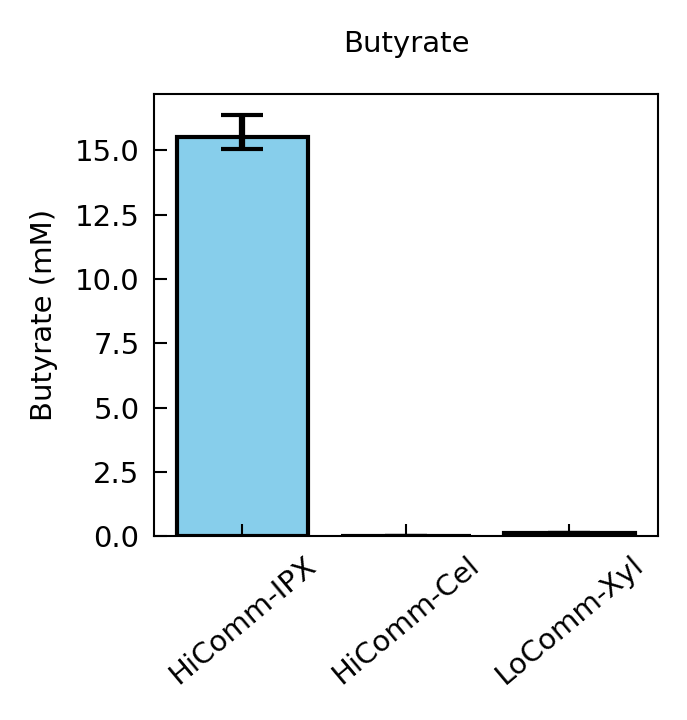

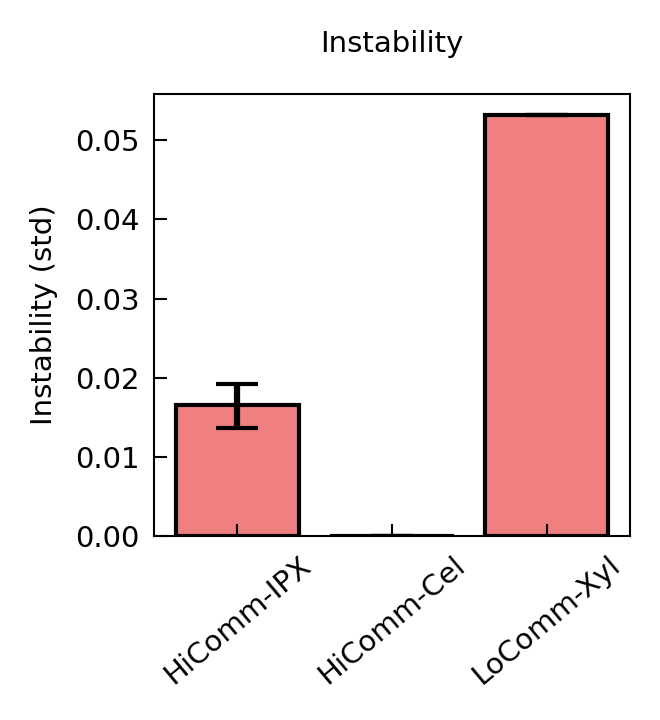

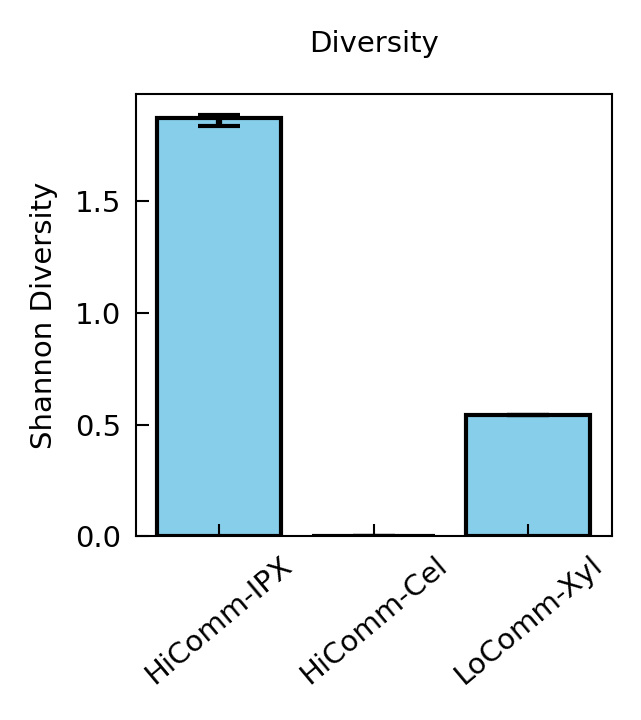

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dict_with_iqr(data_dict, title, ylabel, color='skyblue'):
    keys = list(data_dict.keys())

    # Prepare containers for plotting
    heights = []
    yerr_lower = []
    yerr_upper = []

    for k in keys:
        v = data_dict[k]

        # Handle empty case
        if v is None or len(np.atleast_1d(v)) == 0:
            heights.append(0.0)
            yerr_lower.append(0.0)
            yerr_upper.append(0.0)

        # Handle single value
        elif np.isscalar(v) or len(np.atleast_1d(v)) == 1:
            val = float(np.atleast_1d(v)[0])
            heights.append(val)
            yerr_lower.append(0.0)
            yerr_upper.append(0.0)

        # Handle 3-element array (Q1, median, Q3)
        elif len(v) == 3:
            v = np.array(v)
            median = v[1]
            lower = median - v[0]
            upper = v[2] - median
            heights.append(median)
            yerr_lower.append(lower)
            yerr_upper.append(upper)

        else:
            raise ValueError(f"Unexpected data format for key '{k}': {v}")

    fig, ax = plt.subplots(figsize=(2.3, 2.5))
    ax.bar(
        keys,
        heights,
        yerr=[yerr_lower, yerr_upper],
        capsize=5,
        color=color,
        edgecolor='k'
    )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(keys, rotation=40)

    plt.tight_layout()
    plt.savefig(f'figures/mouse_objectives/{title}_objectives_barplot_invitro.svg')
    plt.show()

plot_dict_with_iqr(butyrate_dict, "Butyrate", "Butyrate (mM)")
plot_dict_with_iqr(instability_dict, "Instability", "Instability (std)", color='lightcoral')
plot_dict_with_iqr(diversity_dict, "Diversity", "Shannon Diversity")